# Inspect mesh alignment

This notebook calls the production `mesh_metrics` alignment code and overlays the prediction and ground truth before and after similarity ICP. Change only the two mesh paths below.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path('/storage/Abhinay/Shell_Gaussian')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from mesh_metrics.alignment import AlignmentConfig, align_meshes, apply_transform
from mesh_metrics.mesh_io import load_mesh, sample_surface

GROUND_TRUTH_PATH = Path(
    '/storage/Abhinay/home_ab5298/dataset/datasets/processed/'
    'golden_set_evaluation_blender/air_jordan_1/reference_mesh.ply'
)
PREDICTION_PATH = Path(
    '/storage/Abhinay/Shell_Gaussian/baselines/NeuralUDF/output/'
    'open_surface_full/air_jordan_1/udf_open/udf_meshes/'
    'udf_res512_step300000.ply'
)

In [3]:
ground_truth = load_mesh(GROUND_TRUTH_PATH)
prediction = load_mesh(PREDICTION_PATH)

config = AlignmentConfig(
    sample_count=50_000,
    coarse_sample_count=5_000,
    candidate_count=4,
    inlier_fraction=0.8,
    seed=0,
)
result = align_meshes(prediction, ground_truth, config)
result.to_dict()

{'transform': [[1.0438258178927227,
   0.015107095511873109,
   -0.005490205836401328,
   0.0015650561580316837],
  [-0.015101389957116509,
   1.0438397346074848,
   0.0011230629020606041,
   0.0010644096923648066],
  [0.005505880156161473,
   -0.0010435104762412351,
   1.043934529155892,
   -6.215869986896539e-05],
  [0.0, 0.0, 0.0, 1.0]],
 'rotation': [[0.999881457730825, 0.014471097019793114, -0.005259071888091029],
  [-0.014465631665028553, 0.9998947885613186, 0.001075782714306435],
  [0.005274086329602307, -0.0009995793917493482, 0.999985592323423]],
 'translation': [0.0015650561580316837,
  0.0010644096923648066,
  -6.215869986896539e-05],
 'scale': 1.0439495700436598,
 'initialization': 'pca_03',
 'converged': True,
 'iterations': 131,
 'before_error': 0.008016900459025008,
 'after_error': 0.00692684643927402,
 'inlier_fraction': 0.8,
 'rotation_determinant': 1.0000000000000002,
 'candidate_errors': {'existing_pose': 0.01123620641125028,
  'pca_03': 0.011235601873829056,
  'pca_

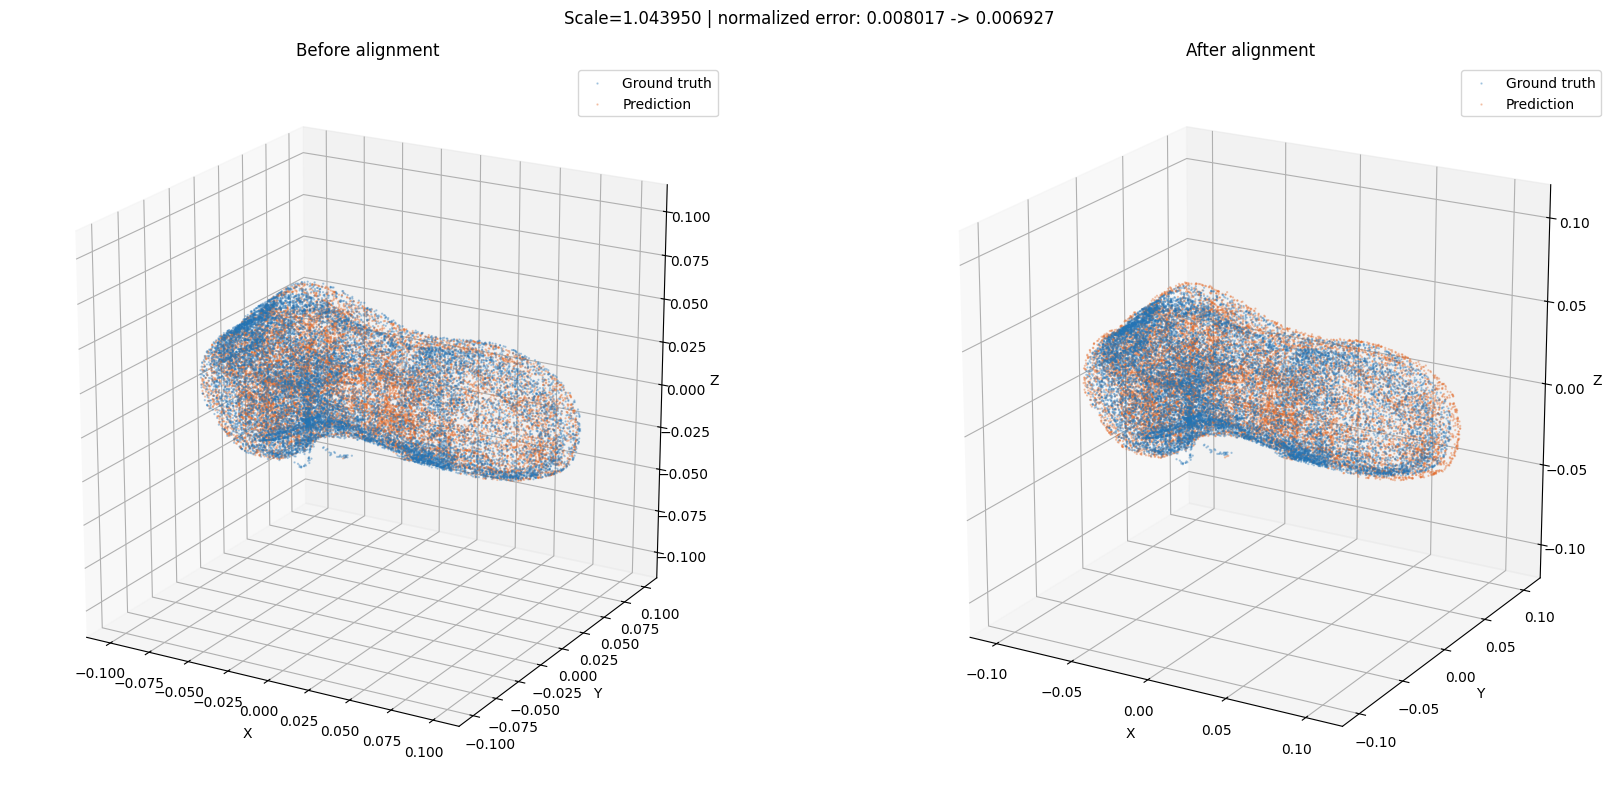

In [4]:
prediction_points, _ = sample_surface(prediction, 15_000, seed=101)
ground_truth_points, _ = sample_surface(ground_truth, 15_000, seed=102)
aligned_points = apply_transform(prediction_points, result.transform)

def set_equal_3d_axes(axis, point_sets):
    combined = np.concatenate(point_sets, axis=0)
    lower = combined.min(axis=0)
    upper = combined.max(axis=0)
    center = 0.5 * (lower + upper)
    radius = 0.55 * float(np.max(upper - lower))
    axis.set_xlim(center[0] - radius, center[0] + radius)
    axis.set_ylim(center[1] - radius, center[1] + radius)
    axis.set_zlim(center[2] - radius, center[2] + radius)
    axis.set_box_aspect((1, 1, 1))
    axis.set_xlabel('X')
    axis.set_ylabel('Y')
    axis.set_zlabel('Z')

fig = plt.figure(figsize=(18, 8))
views = [
    ('Before alignment', prediction_points),
    ('After alignment', aligned_points),
]
for index, (title, shown_prediction) in enumerate(views, start=1):
    axis = fig.add_subplot(1, 2, index, projection='3d')
    axis.scatter(*ground_truth_points.T, s=0.4, c='#2474b5', alpha=0.35, label='Ground truth')
    axis.scatter(*shown_prediction.T, s=0.4, c='#e46c2c', alpha=0.35, label='Prediction')
    set_equal_3d_axes(axis, [ground_truth_points, shown_prediction])
    axis.view_init(elev=20, azim=-60)
    axis.set_title(title)
    axis.legend(loc='upper right')

fig.suptitle(
    f'Scale={result.scale:.6f} | normalized error: '
    f'{result.before_error:.6f} -> {result.after_error:.6f}'
)
plt.tight_layout()
plt.show()

In [ ]:
from mesh_metrics.geometry_metrics import GeometryMetricConfig, compute_geometry_metrics
from mesh_metrics.mesh_io import transform_mesh

aligned_mesh = transform_mesh(prediction, result.transform)
geometry_metrics = compute_geometry_metrics(
    aligned_mesh,
    ground_truth,
    GeometryMetricConfig(sample_count=200_000, seed=10_000),
)
geometry_metrics['headline']

In [ ]:
# Full held-out rendering is optional because it processes 30 images at 1536x1024.
RUN_HELDOUT_METRICS = False
if RUN_HELDOUT_METRICS:
    from mesh_metrics.render_metrics import (
        compute_heldout_metrics,
        validate_reference_render,
    )
    scene_root = GROUND_TRUTH_PATH.parent
    diagonal = geometry_metrics['ground_truth_bbox_diagonal']
    reference_validation = validate_reference_render(ground_truth, scene_root, diagonal)
    heldout_metrics = compute_heldout_metrics(aligned_mesh, scene_root, diagonal)
    display(reference_validation)
    display(heldout_metrics['headline'])

## What to verify

The blue ground truth and orange prediction should overlap in position, overall size, toe/heel direction, and sole/up direction after alignment. Missing heels, straps, openings, or noisy sheets should remain visible; alignment must not repair geometry.